# Comparison between installed capacities in Denmark 2025
This notebook aims to compare the installed electricities in Denmark 2025, using the powerplantmatching dataset, data from Energistyrelsen and the output of the network model generated from PyPSA-eur.

## Load data and networks
First load the data from the csv files and network file

In [ ]:
import pandas as pd
import pypsa
from pathlib import Path
import matplotlib.pyplot as plt

# The notebook is located in the "notebooks" directory
ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT_DIR / "data"
NET_DIR = DATA_DIR / "networks"

# Load powerplant data
df_ens = pd.read_csv(DATA_DIR / "powerplants.csv")
df_ppm = pd.read_csv(DATA_DIR / "powerplants_PPM.csv")

# Raw Energistyrelsen data
df_ens_pp = pd.read_csv(
        DATA_DIR / "ENS_power_plant_register.csv",
        sep=";",
        decimal=",",
    )

# Load network
OG_network = pypsa.Network(NET_DIR / "base_s_3_OG.nc") # Original from powerplantmatching
OGI_network = pypsa.Network(NET_DIR / "base_s_3_OG_Irena.nc") # Original from powerplantmatching + IRENA
ENS_network = pypsa.Network(NET_DIR / "base_s_3_updated_PPM.nc") # Data from Energistyrelsen
TEST_network = pypsa.Network(NET_DIR / "base_s_3__ext.nc") # TEST networks to compare with ENS

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


---

## Compare powerplantmatching original powerplants.csv and the modified powerplants.csv using Energistyrelsens data

Here we only compare the power capacitites

Installed capacities per fueltype in Denmark active in 2025 [MW]:
                      ENS     PPM
Fueltype                         
Biogas          116.23600     0.0
Hard Coal       385.00000   716.0
Hydro             6.93900     0.0
Natural Gas    1780.21200  1461.2
Oil             732.61000   126.0
Solar          5068.32368  3364.9
Solid Biomass  1883.62800  1781.0
Waste           388.09000   153.0
Wind           7499.92134  4609.4


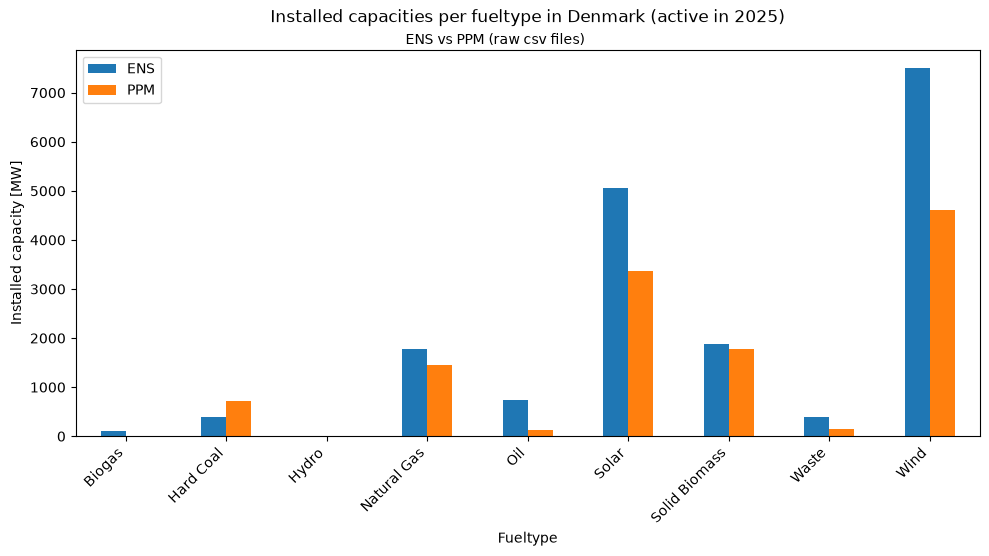

In [4]:

def active_in_year(df, year):
    is_dk = df["Country"] == "Denmark"
    is_in = df["DateIn"] <= year
    is_not_out = df["DateOut"].isna() | (df["DateOut"] >= year)
    return df.loc[is_dk & is_in & is_not_out]

YEAR = 2025

# lets look at the installed capacities per fueltype in Denmark active in the given year

df_ens_dk = active_in_year(df_ens, YEAR)
df_ppm_dk = active_in_year(df_ppm, YEAR)

cap_ens = df_ens_dk.groupby("Fueltype")["Capacity"].sum() # MW
cap_ppm = df_ppm_dk.groupby("Fueltype")["Capacity"].sum() # MW

comparison = pd.concat([cap_ens, cap_ppm], axis=1, keys=["ENS", "PPM"]).fillna(0)
print(f"Installed capacities per fueltype in Denmark active in {YEAR} [MW]:")
print(comparison)

comparison.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Installed capacity [MW]")
plt.title(f"Installed capacities per fueltype in Denmark (active in {YEAR})", y = 1.05)
plt.suptitle("ENS vs PPM (raw csv files)", fontsize=10, y=0.88)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Installed capacities per technology in Denmark active in 2025 [MW]:
                          ENS     PPM
Technology                           
CCGT                855.94000   711.2
Combustion Engine  1016.65600     0.0
OCGT                351.10000     0.0
Offshore           2598.50004  2652.6
Onshore            4879.76300  1956.8
PV                 5068.32368  3359.4
Run-Of-River          6.93900     0.0
Steam Turbine      3057.13000  1672.0
Csp                   0.00000     5.5


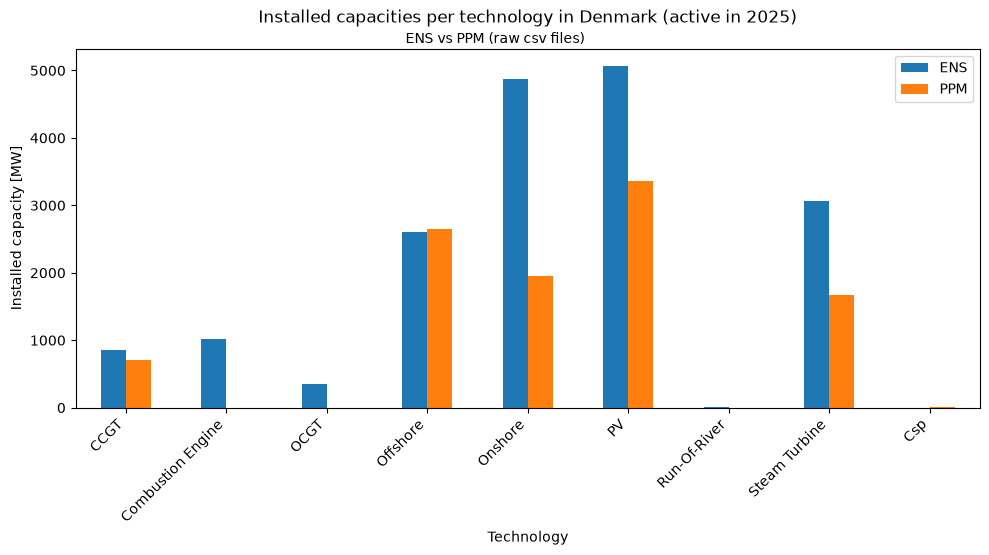

In [5]:
# Lets look at the total installed capacities per technology in Denmark active in the given year

cap_ens = df_ens_dk.groupby("Technology")["Capacity"].sum() # MW
cap_ppm = df_ppm_dk.groupby("Technology")["Capacity"].sum() # MW

comparison = pd.concat([cap_ens, cap_ppm], axis=1, keys=["ENS", "PPM"]).fillna(0)
print(f"Installed capacities per technology in Denmark active in {YEAR} [MW]:")
print(comparison)

comparison.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Installed capacity [MW]")
plt.title(f"Installed capacities per technology in Denmark (active in {YEAR})", y = 1.05)
plt.suptitle("ENS vs PPM (raw csv files)", fontsize=10, y=0.88)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---

## Investigating the heat capacitites from Energistyrelsens data


In [10]:
# Filter Energistyrelsen installations active at the end of 2025
END_2025 = pd.Timestamp(f"{YEAR}-12-31")

df_ens_pp["idriftdato"] = pd.to_datetime(
    df_ens_pp["idriftdato"], errors="coerce"
)
df_ens_pp["skrotdato"] = pd.to_datetime(
    df_ens_pp["skrotdato"], errors="coerce"
)

active_mask = (
    (df_ens_pp["idriftdato"].isna() | (df_ens_pp["idriftdato"] <= END_2025))
    & (df_ens_pp["skrotdato"].isna() | (df_ens_pp["skrotdato"] > END_2025))
    & (df_ens_pp["Hovedbrændselsgruppe"] != "Ej i drift i 2025")
)

df_ens_pp_active = df_ens_pp.loc[active_mask].copy()


In [14]:
# if df_ens_pp_active['fv_net'] is not empty, it supplies to district heating
if not df_ens_pp_active['fv_net'].empty:
    df_ens_pp_active['supplies_to_district_heating'] = True
else:
    df_ens_pp_active['supplies_to_district_heating'] = False

# sum the 'varmekapacitet_MW' for installations that supply to district heating
total_dh_MW = df_ens_pp_active.loc[
    df_ens_pp_active['supplies_to_district_heating'], 'varmekapacitet_MW'
].sum()

print(f"Total district heating capacity: {total_dh_MW} MW (source: Energistyrelsen 2025)")

Total district heating capacity: 22779.2096 MW (source: Energistyrelsen 2025)


In [ ]:
# sum each 'anlaegstype_navn' that supplies to district heating, this is installed capacity before efficiency losses
total_dh_by_type = df_ens_pp_active.loc[
    df_ens_pp_active['supplies_to_district_heating']
].groupby('anlaegstype_navn')['varmekapacitet_MW'].sum()

print("Total district heating capacity by type:")
print(total_dh_by_type)

Total district heating capacity by type:
anlaegstype_navn
Anden                           10.5000
Bioforgasn. m. FM               41.5600
Bioforgasn. m. KE                5.5000
Dampkedel                       44.0000
Dampturbine                   5296.5700
Elpatron                      2047.0950
Forbrændingsmotor             1087.9296
Gasturbine                     234.7000
Geotermi                         8.3000
Kedel                        10766.8390
Kombianlæg                     977.4000
Nødstrømsanlæg                   2.5900
Organic Rankine (ORC)           34.0000
Overskudsvarme                 335.8050
Solvarme                      1090.2950
Vandkraft                        0.0000
Varmepumpe                      18.4410
Varmepumpe Anden                33.7560
Varmepumpe Grundvand            15.9680
Varmepumpe Havvand              35.0000
Varmepumpe Kombi                 9.0000
Varmepumpe Luft                464.2870
Varmepumpe Overskudsvarme      110.9050
Varmepumpe Solvarme   

In [ ]:
# print all buses from ENS_network that contains "heat"
ENS_network.buses[ENS_network.buses["carrier"].str.contains("heat", case=False, na=False)]

# sum all urban central heating capacities in Denmark that goes into the buses urban central heating


np.float64(0.0)

-----------------------------------------------------------------------------------------------------------------------

### Comparing different network files
Now we can look further into the generated network files with different input data and config files from PyPSA-Eur

In [16]:
def dk_ac_capacity_by_carrier(network):
    dk_ac_buses = network.buses.index[
        network.buses["carrier"].isin(["AC", "DC"])
        & (network.buses["country"] == "DK")
    ]

    gens = network.generators.loc[
        network.generators["bus"].isin(dk_ac_buses), ["carrier", "p_nom_opt"]
    ]
    storage = network.storage_units.loc[
        network.storage_units["bus"].isin(dk_ac_buses), ["carrier", "p_nom_opt"]
    ]

    links = network.links.loc[
        network.links["bus1"].isin(dk_ac_buses), ["carrier", "p_nom_opt"]
    ]

    components = pd.concat([gens, storage, links])
    return components.groupby("carrier")["p_nom_opt"].sum()


cap_ens_ac = dk_ac_capacity_by_carrier(ENS_network)

cap_ext_ac = dk_ac_capacity_by_carrier(EXT_network)

# Compare the AC capacities for Denmark between the original and Energistyrelsen networks
df_el = pd.DataFrame({
    "Energistyrelsen Normal": cap_ens_ac,
    "Energistyrelsen Extended": cap_ext_ac
})
df_el



,Energistyrelsen Normal,Energistyrelsen Extended
carrier,,
CCGT,0.088699,0.088684
DC,1880.000000,1880.000000
OCGT,1052.216063,1052.665083
biomass,0.095883,0.093702
coal,0.062281,0.060709
electricity distribution grid,5216.926120,5217.074739
lignite,0.076184,0.073929
nuclear,0.008598,0.008671
offwind-ac,2574.900040,2574.900040


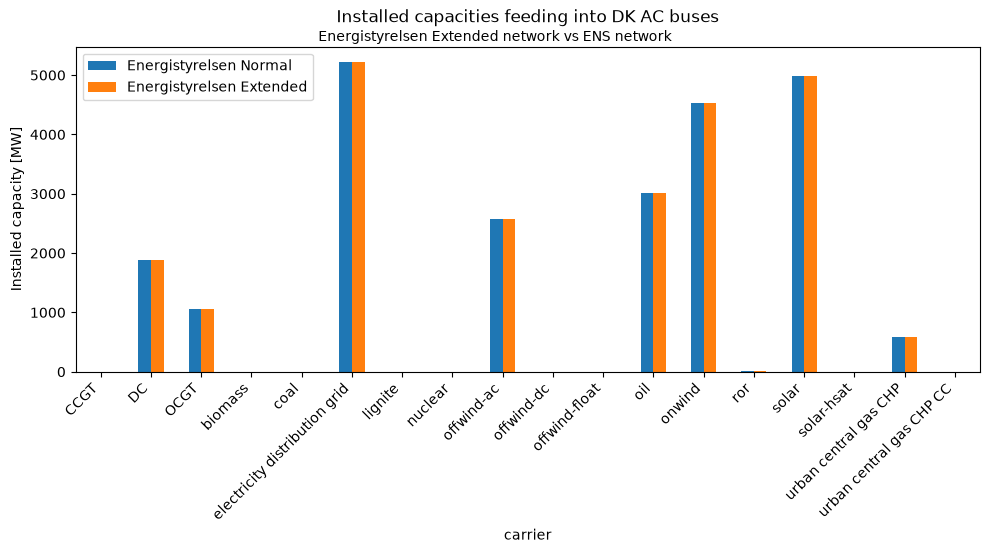

In [17]:
ac_comparison = pd.concat(
    [cap_ens_ac, cap_ext_ac], axis=1, keys=["Energistyrelsen Normal", "Energistyrelsen Extended"]
).fillna(0)

ac_comparison.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Installed capacity [MW]")
plt.title("Installed capacities feeding into DK AC buses", y=1.05)
plt.suptitle("Energistyrelsen Extended network vs ENS network", fontsize=10, y=0.88)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [28]:
def dk_heat_capacity_by_carrier(network):
    dk_heat_buses = network.buses.index[
        network.buses["carrier"].str.contains("heat", case=False, na=False)
        & (network.buses["country"] == "DK")
    ]

    gens = network.generators.loc[
        network.generators["bus"].isin(dk_heat_buses), ["carrier", "p_nom_opt"]
    ]
    storage = network.storage_units.loc[
        network.storage_units["bus"].isin(dk_heat_buses), ["carrier", "p_nom_opt"]
    ]

    links = network.links.loc[
        network.links["bus0"].isin(dk_heat_buses), ["carrier", "p_nom_opt"]
    ]

    

    components = pd.concat([gens, storage, links])
    
    return components.groupby("carrier")["p_nom_opt"].sum()


cap_ppm_heat = dk_heat_capacity_by_carrier(OG_network)

cap_ens_heat = dk_heat_capacity_by_carrier(ENS_network)

# Compare the heat capacities for Denmark between the original and Energistyrelsen networks
df_heat = pd.DataFrame({
    "Original Network": cap_ppm_heat,
    "Energistyrelsen Network": cap_ens_heat
})
df_heat


,Original Network,Energistyrelsen Network
carrier,,
rural air heat pump,0.195946,0.441101
rural ground heat pump,782.104234,799.473383
rural heat vent,0.042619,5.202815
rural solar thermal,0.069489,0.110353
rural water tanks charger,1.865843,3.168449
urban central air heat pump,738.262533,900.528102
urban central heat vent,0.018019,0.781587
urban central solar thermal,0.121012,0.182028
urban central water pits charger,1879.968744,2292.275820


In [19]:
# sum from cap_ens_heat for only containing 'central'
sum_central_heat_ens = cap_ens_heat.loc[cap_ens_heat.index.str.contains(" central")].sum()
print(sum_central_heat_ens)

# sum for all
sum_all_heat_ens = df_heat['Energistyrelsen Network'].sum()
print(sum_all_heat_ens)

10953.93809861814
16927.849383091343


In [ ]:
df_heat

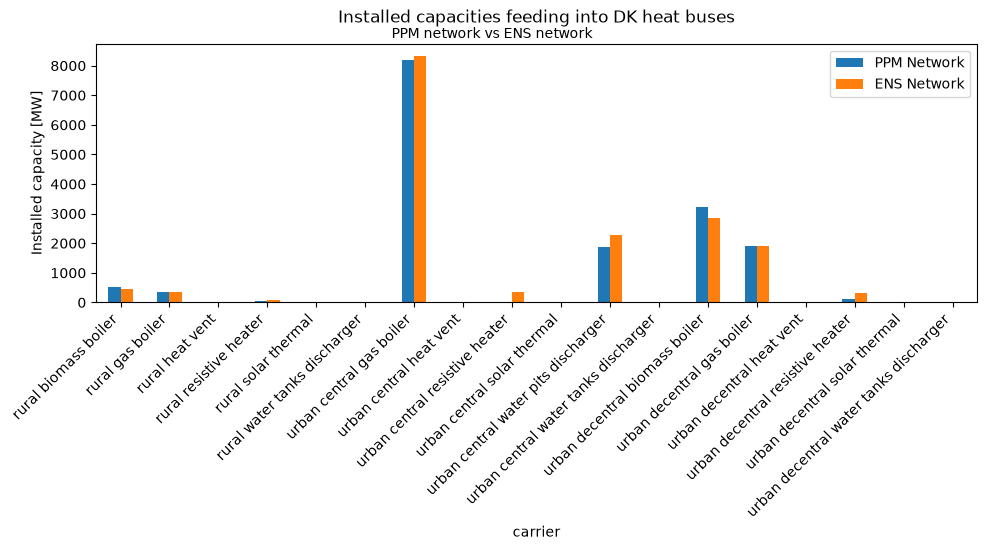

In [20]:
heat_comparison = pd.concat(
    [cap_ppm_heat, cap_ens_heat], axis=1, keys=["PPM Network", "ENS Network"]
).fillna(0)

heat_comparison.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Installed capacity [MW]")
plt.title("Installed capacities feeding into DK heat buses", y=1.05)
plt.suptitle("PPM network vs ENS network", fontsize=10, y=0.88)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
# Check total heat capacity of installed heat from df_ens_pp active in 2025


total_heat_capacity = df_ens_pp["varmekapacitet_MW"].sum()
print(f'Total installed heat capacity from Energistyrelsen data: {total_heat_capacity} MW')

# check how much of it is from combined heat and power (CHP) plants
chp_heat_capacity = df_ens_pp[df_ens_pp["elkapacitet_MW"] > 0]["varmekapacitet_MW"].sum()
print(f'Total installed heat capacity from CHP plants: {chp_heat_capacity} MW')

chp_power_capacity = df_ens_pp[(df_ens_pp["elkapacitet_MW"] > 0) & (df_ens_pp["varmekapacitet_MW"] > 0)]["elkapacitet_MW"].sum()
print(f'Total installed power capacity from CHP plants: {chp_power_capacity} MW')

# chp_power + chp_heat gives the total installed capacity of CHP plants
total_chp_capacity = chp_power_capacity + chp_heat_capacity
print(f'Total installed capacity from CHP plants: {total_chp_capacity} MW')

In [ ]:
# sum df heat energistyrelsen 
sum_network_ens = df_heat['Energistyrelsen Network'].sum()

In [ ]:
# check all anlaegtype_navn where varmekapacitet > 0
df_ens_pp[df_ens_pp["varmekapacitet_MW"] > 0]["anlaegstype_navn"].unique()

# sum for each anlaegstype_navn where varmekapacitet > 0
df_ens_pp[df_ens_pp["varmekapacitet_MW"] > 0].groupby("anlaegstype_navn")["varmekapacitet_MW"].sum()

In [ ]:
# Sum varmekapacitet_MW where fv_net_navn contains "fjernvarme"
mask = df_ens_pp["fv_net_navn"].str.contains(
    "fjernvarme",
    case=False,
    na=False,
)

sum_central_heat_pp = df_ens_pp.loc[
    mask, "varmekapacitet_MW"
].sum()

print(sum_central_heat_pp)

In [ ]:
heat_capacity_by_type = (
    df_ens_pp.loc[df_ens_pp["varmekapacitet_MW"] > 0]
    .groupby("anlaegstype_navn")["varmekapacitet_MW"]
    .sum()
    .sort_values(ascending=False)
)

ax = heat_capacity_by_type.plot(kind="bar", figsize=(12, 6))
ax.set_xlabel("Anlaegstype")
ax.set_ylabel("Total heat capacity [MW]")
ax.set_title("Total heat capacity by anlaegstype_navn")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# print all buses for Denmark in ENS network
ens_dk_buses = ENS_network.buses.index[ENS_network.buses["country"] == "DK"]
ENS_network.buses.loc[ens_dk_buses]